# Smíšený PINN pro 2D lineární elastostatiku

Cílem je současně aproximovat dvě složky posunutí a tři složky symetrického tenzoru napětí na oblasti

$$
\Omega=(0,1)^2.
$$

Síť má pět fyzikálních výstupů

$$
\mathbf q_\theta(x,y)
=
\begin{bmatrix}
u_{1,\theta} & u_{2,\theta} &
\sigma_{xx,\theta} & \sigma_{yy,\theta} & \sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$
Přesné řešení posunutí bylo zvoleno jako

$$
\mathbf u_{\mathrm{exact}}(x,y)
=
a
\begin{bmatrix}
\cos x-y^2\\
2\sin x+y
\end{bmatrix},
\qquad a=0.005.
$$

Materiálové parametry jsou

$$
E=1,
\qquad
\nu=\frac14,
\qquad
\lambda=\mu=\frac25.
$$

## Silná forma

Tenzor malých deformací je

$$
\boldsymbol\varepsilon(\mathbf u)
=
\frac12\left(\nabla\mathbf u+\nabla\mathbf u^{\mathsf T}\right),
$$

a konstitutivní vztah má tvar

$$
\boldsymbol\sigma
=
\lambda\operatorname{tr}(\boldsymbol\varepsilon)\mathbf I
+2\mu\boldsymbol\varepsilon.
$$

Rovnice rovnováhy je

$$
\nabla\cdot\boldsymbol\sigma+\mathbf b=\mathbf0
\qquad\text{v }\Omega.
$$

Pro zvolené přesné řešení vychází

$$
\boldsymbol\varepsilon
=
\begin{bmatrix}
-a\sin x & a(\cos x-y)\\
a(\cos x-y) & a
\end{bmatrix},
$$

$$
\operatorname{tr}(\boldsymbol\varepsilon)
=a(1-\sin x),
$$

a při $\lambda=\mu=2/5$

$$
\boldsymbol\sigma_{\mathrm{exact}}(x,y)
=
\begin{bmatrix}
\dfrac{2a}{5}(1-3\sin x) & \dfrac{4a}{5}(\cos x-y)\\[0.6em]
\dfrac{4a}{5}(\cos x-y) & \dfrac{2a}{5}(3-\sin x)
\end{bmatrix}.
$$

Objemová síla, která zajišťuje rovnováhu přesného řešení, je

$$
\mathbf b(x,y)
=
\begin{bmatrix}
\dfrac{6a}{5}\cos x+\dfrac{4a}{5}\\[0.6em]
\dfrac{4a}{5}\sin x
\end{bmatrix}.
$$

## Smíšené okrajové podmínky

Na levé a pravé hraně předepisujeme přesné posunutí. Na dolní a horní hraně předepisujeme přesnou trakci $\mathbf t=\boldsymbol\sigma\mathbf n$.

Na $x=0$ platí

$$
\mathbf u(0,y)
=a
\begin{bmatrix}
1-y^2\\y
\end{bmatrix},
$$

a na $x=1$

$$
\mathbf u(1,y)
=a
\begin{bmatrix}
\cos1-y^2\\2\sin1+y
\end{bmatrix}.
$$

Na horní hraně $y=1$, kde $\mathbf n=(0,1)^{\mathsf T}$, je

$$
\mathbf t_{\mathrm{top}}(x)
=
\begin{bmatrix}
\dfrac{4a}{5}(\cos x-1)\\[0.6em]
\dfrac{2a}{5}(3-\sin x)
\end{bmatrix}.
$$

Na dolní hraně $y=0$, kde $\mathbf n=(0,-1)^{\mathsf T}$, je

$$
\mathbf t_{\mathrm{bottom}}(x)
=
\begin{bmatrix}
-\dfrac{4a}{5}\cos x\\[0.6em]
-\dfrac{2a}{5}(3-\sin x)
\end{bmatrix}.
$$


## 1. Import knihoven


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Nastavení parametrů

- `USE_DATA = False`: čistý smíšený PINN.
- `USE_DATA = True`: přidá se loss známých hodnot všech pěti polí.
- Prvních 1900 epoch používá Adam a posledních 100 epoch L-BFGS.

In [2]:
USE_DATA = True

E = 1.0
NU = 1.0 / 4.0
LAMBDA = 2.0 / 5.0
MU = 2.0 / 5.0
AMPLITUDE = 0.005

N_PDE_TRAIN = 2000
N_PDE_VALIDATION = 1000
N_PDE_TEST = 2000
N_BOUNDARY_PER_EDGE = 100
N_DATA_TRAIN = 70
N_DATA_VALIDATION = 20
N_DATA_TEST = 20

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))

print(f"E z Lameho konstant:  {E_FROM_LAME:.6f}")
print(f"nu z Lameho konstant: {NU_FROM_LAME:.6f}")


E z Lameho konstant:  1.000000
nu z Lameho konstant: 0.250000


## 3. Přesné posunutí, napětí, objemová síla a trakce


In [3]:
def exact_displacement(xy):
    """Presne posunuti [u1, u2]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]

    u1 = AMPLITUDE * (torch.cos(x) - y**2)
    u2 = AMPLITUDE * (2.0 * torch.sin(x) + y)
    return torch.cat((u1, u2), dim=1)


def exact_stress(xy):
    """Presne slozky [sigma_xx, sigma_yy, sigma_xy]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    a = AMPLITUDE

    eps_xx = -a * torch.sin(x)
    eps_yy = a * torch.ones_like(x)
    eps_xy = a * (torch.cos(x) - y)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def exact_fields(xy):
    """Vsech pet presnych poli [u1, u2, sxx, syy, sxy]."""
    return torch.cat((exact_displacement(xy), exact_stress(xy)), dim=1)


def body_force(xy):
    """b = -div(sigma_exact)."""
    x = xy[:, 0:1]
    a = AMPLITUDE

    b1 = a * (LAMBDA + 2.0 * MU) * torch.cos(x) + 2.0 * MU * a
    b2 = 2.0 * MU * a * torch.sin(x)
    return torch.cat((b1, b2), dim=1)


def exact_traction(xy, normals):
    """Presna trakce t = sigma_exact*n."""
    stress = exact_stress(xy)
    sigma_xx = stress[:, 0:1]
    sigma_yy = stress[:, 1:2]
    sigma_xy = stress[:, 2:3]

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    return torch.cat((traction_x, traction_y), dim=1)


## 4. Neuronová síť s pěti výstupy

Výstupy sítě mají pořadí

$$
[u_{1,\theta},u_{2,\theta},\sigma_{xx,\theta},
\sigma_{yy,\theta},\sigma_{xy,\theta}].
$$


In [4]:
class MixedPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 5),
        )

    def forward(self, xy):
        return self.net(xy)


model = MixedPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Training, validation, test, and boundary points

Validation points are fixed and are not used by either optimizer.


In [5]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = torch.rand(N_PDE_TRAIN, 2, generator=pde_train_generator)
xy_pde_train.requires_grad_(True)

pde_validation_generator = torch.Generator().manual_seed(SEED + 10)
xy_pde_validation = torch.rand(N_PDE_VALIDATION, 2, generator=pde_validation_generator)
xy_pde_validation.requires_grad_(True)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = torch.rand(N_PDE_TEST, 2, generator=pde_test_generator)
xy_pde_test.requires_grad_(True)

t = torch.linspace(0.0, 1.0, N_BOUNDARY_PER_EDGE).view(-1, 1)
left = torch.cat((torch.zeros_like(t), t), dim=1)
right = torch.cat((torch.ones_like(t), t), dim=1)
xy_dirichlet = torch.cat((left, right), dim=0)
u_dirichlet = exact_displacement(xy_dirichlet)
bottom = torch.cat((t, torch.zeros_like(t)), dim=1)
top = torch.cat((t, torch.ones_like(t)), dim=1)
normal_bottom = torch.cat((torch.zeros_like(t), -torch.ones_like(t)), dim=1)
normal_top = torch.cat((torch.zeros_like(t), torch.ones_like(t)), dim=1)
xy_neumann = torch.cat((bottom, top), dim=0)
normals_neumann = torch.cat((normal_bottom, normal_top), dim=0)
traction_neumann = exact_traction(xy_neumann, normals_neumann)

if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = torch.rand(N_DATA_TRAIN, 2, generator=data_train_generator)
    fields_data_train = exact_fields(xy_data_train)
    data_validation_generator = torch.Generator().manual_seed(SEED + 11)
    xy_data_validation = torch.rand(N_DATA_VALIDATION, 2, generator=data_validation_generator)
    fields_data_validation = exact_fields(xy_data_validation)
    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = torch.rand(N_DATA_TEST, 2, generator=data_test_generator)
    fields_data_test = exact_fields(xy_data_test)


## 6. Rovnovážné a konstitutivní reziduum

Protože síť predikuje napětí samostatně, fyzikální loss obsahuje dvě části.

Rovnovážné reziduum je

$$
\mathbf r_{\mathrm{eq},\theta}
=
\nabla\cdot\boldsymbol\sigma_\theta+\mathbf b.
$$

Konstitutivní reziduum spojuje predikované napětí s predikovaným posunutím:

$$
\mathbf r_{\mathrm{const},\theta}
=
\boldsymbol\sigma_\theta
-
\left[
\lambda\operatorname{tr}(\boldsymbol\varepsilon(\mathbf u_\theta))\mathbf I
+2\mu\boldsymbol\varepsilon(\mathbf u_\theta)
\right].
$$

Celková loss je

$$
\mathcal L
=
\mathcal L_{\mathrm{eq}}
+\mathcal L_{\mathrm{const}}
+\mathcal L_{\mathrm D}
+\mathcal L_{\mathrm N}
+\mathcal L_{\mathrm{data}}.
$$

Pro `USE_DATA = False` je $\mathcal L_{\mathrm{data}}=0$.


In [6]:
def split_prediction(prediction):
    u1 = prediction[:, 0:1]
    u2 = prediction[:, 1:2]
    sigma_xx = prediction[:, 2:3]
    sigma_yy = prediction[:, 3:4]
    sigma_xy = prediction[:, 4:5]
    return u1, u2, sigma_xx, sigma_yy, sigma_xy


def constitutive_stress_from_displacement(
    xy,
    u1,
    u2,
    create_graph,
):
    grad_u1 = torch.autograd.grad(
        u1,
        xy,
        grad_outputs=torch.ones_like(u1),
        create_graph=create_graph,
        retain_graph=True,
    )[0]
    grad_u2 = torch.autograd.grad(
        u2,
        xy,
        grad_outputs=torch.ones_like(u2),
        create_graph=create_graph,
        retain_graph=True,
    )[0]

    eps_xx = grad_u1[:, 0:1]
    eps_yy = grad_u2[:, 1:2]
    eps_xy = 0.5 * (grad_u1[:, 1:2] + grad_u2[:, 0:1])
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def mixed_residuals(xy, training=True):
    prediction = model(xy)
    u1, u2, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)

    constitutive_stress = constitutive_stress_from_displacement(
        xy,
        u1,
        u2,
        create_graph=training,
    )
    predicted_stress = torch.cat(
        (sigma_xx, sigma_yy, sigma_xy),
        dim=1,
    )
    residual_constitutive = predicted_stress - constitutive_stress

    grad_sigma_xx = torch.autograd.grad(
        sigma_xx,
        xy,
        grad_outputs=torch.ones_like(sigma_xx),
        create_graph=training,
        retain_graph=True,
    )[0]
    grad_sigma_yy = torch.autograd.grad(
        sigma_yy,
        xy,
        grad_outputs=torch.ones_like(sigma_yy),
        create_graph=training,
        retain_graph=True,
    )[0]
    grad_sigma_xy = torch.autograd.grad(
        sigma_xy,
        xy,
        grad_outputs=torch.ones_like(sigma_xy),
        create_graph=training,
        retain_graph=True,
    )[0]

    b = body_force(xy)
    residual_1 = (
        grad_sigma_xx[:, 0:1]
        + grad_sigma_xy[:, 1:2]
        + b[:, 0:1]
    )
    residual_2 = (
        grad_sigma_xy[:, 0:1]
        + grad_sigma_yy[:, 1:2]
        + b[:, 1:2]
    )
    residual_equilibrium = torch.cat((residual_1, residual_2), dim=1)

    return residual_equilibrium, residual_constitutive, prediction


def compute_losses():
    residual_eq, residual_const, _ = mixed_residuals(
        xy_pde_train,
        training=True,
    )
    loss_equilibrium = torch.mean(residual_eq**2)
    loss_constitutive = torch.mean(residual_const**2)

    dirichlet_prediction = model(xy_dirichlet)[:, 0:2]
    loss_dirichlet = torch.mean(
        (dirichlet_prediction - u_dirichlet) ** 2
    )

    neumann_prediction = model(xy_neumann)
    _, _, sigma_xx, sigma_yy, sigma_xy = split_prediction(
        neumann_prediction
    )
    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]
    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    traction_prediction = torch.cat((traction_x, traction_y), dim=1)
    loss_neumann = torch.mean(
        (traction_prediction - traction_neumann) ** 2
    )
    loss_boundary = loss_dirichlet + loss_neumann

    if USE_DATA:
        data_prediction = model(xy_data_train)
        loss_data = torch.mean(
            (data_prediction - fields_data_train) ** 2
        )
    else:
        loss_data = torch.tensor(0.0)

    loss = (
        loss_equilibrium
        + loss_constitutive
        + loss_boundary
        + loss_data
    )

    return (
        loss,
        loss_equilibrium,
        loss_constitutive,
        loss_boundary,
        loss_data,
    )


def compute_validation_losses():
    residual_eq, residual_const, _ = mixed_residuals(xy_pde_validation, training=False)
    loss_validation_equilibrium = torch.mean(residual_eq.detach()**2)
    loss_validation_constitutive = torch.mean(residual_const.detach()**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(xy_data_validation) - fields_data_validation)**2) if USE_DATA else loss_validation_equilibrium.new_tensor(0.0)
    loss_validation = loss_validation_equilibrium + loss_validation_constitutive + loss_validation_data
    return loss_validation, loss_validation_equilibrium, loss_validation_constitutive, loss_validation_data


## 7. Training, validation, and best-epoch selection


In [7]:
loss_history, equilibrium_loss_history, constitutive_loss_history = [], [], []
boundary_loss_history, data_loss_history = [], []
validation_loss_history, validation_equilibrium_loss_history = [], []
validation_constitutive_loss_history, validation_data_loss_history = [], []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float("inf")
best_validation_equilibrium_loss = None
best_validation_constitutive_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None

def clone_model_state():
    return {name: value.detach().clone() for name, value in model.state_dict().items()}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_equilibrium_loss, best_validation_constitutive_loss, best_validation_data_loss, best_epoch, best_model_state
    validation, validation_eq, validation_const, validation_data = compute_validation_losses()
    values = validation.item(), validation_eq.item(), validation_const.item(), validation_data.item()
    validation_loss_history.append(values[0])
    validation_equilibrium_loss_history.append(values[1])
    validation_constitutive_loss_history.append(values[2])
    validation_data_loss_history.append(values[3])
    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss, best_validation_equilibrium_loss, best_validation_constitutive_loss, best_validation_data_loss = values
        best_epoch = epoch
        best_model_state = clone_model_state()
    return values[0]

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode="min", factor=0.5, patience=200)

for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    xy_pde_train.grad = None
    losses = compute_losses()
    loss, loss_eq, loss_const, loss_bc, loss_data = losses
    loss.backward()
    optimizer_adam.step()
    scheduler.step(loss.item())
    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    boundary_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if epoch % 500 == 0:
        print(f"Adam | epocha {epoch:5d} | loss={loss.item():.6e} | eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | BC={loss_bc.item():.6e} | data={loss_data.item():.6e} | validation={validation_value:.6e}")

print(f"Switching from Adam to L-BFGS at epoch {ADAM_EPOCHS}.")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch
    def closure():
        optimizer_lbfgs.zero_grad()
        xy_pde_train.grad = None
        loss = compute_losses()[0]
        loss.backward()
        return loss
    optimizer_lbfgs.step(closure)
    loss, loss_eq, loss_const, loss_bc, loss_data = compute_losses()
    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    boundary_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f"L-BFGS | epocha {epoch:5d} | loss={loss.item():.6e} | eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | BC={loss_bc.item():.6e} | data={loss_data.item():.6e} | validation={validation_value:.6e}")

last_model_state = clone_model_state()
model.load_state_dict(best_model_state)
model.eval()
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.6e}")


Adam | epocha     0 | loss=1.262502e-01 | eq=3.361859e-04 | const=3.691188e-02 | BC=6.329291e-02 | data=2.570927e-02 | validation=5.569554e-02
Adam | epocha   500 | loss=4.586915e-06 | eq=2.225809e-06 | const=1.590611e-06 | BC=5.620286e-07 | data=2.084672e-07 | validation=4.230210e-06
Adam | epocha  1000 | loss=2.129517e-06 | eq=5.808961e-07 | const=9.864434e-07 | BC=4.063903e-07 | data=1.557870e-07 | validation=1.784738e-06
Adam | epocha  1500 | loss=1.405084e-06 | eq=3.300838e-07 | const=6.541936e-07 | BC=2.991712e-07 | data=1.216350e-07 | validation=1.134993e-06
Switching from Adam to L-BFGS at epoch 1900.
L-BFGS | epocha  1900 | loss=1.062399e-06 | eq=2.647964e-07 | const=4.722592e-07 | BC=2.277545e-07 | data=9.758878e-08 | validation=8.535102e-07
L-BFGS | epocha  1950 | loss=1.062399e-06 | eq=2.647964e-07 | const=4.722592e-07 | BC=2.277545e-07 | data=9.758878e-08 | validation=8.535102e-07
L-BFGS | epocha  1999 | loss=1.062399e-06 | eq=2.647964e-07 | const=4.722592e-07 | BC=2.27754

## 8. Testing the restored best model on independent points


In [8]:
model.eval()
xy_pde_test.grad = None
residual_eq_test, residual_const_test, prediction_test = mixed_residuals(xy_pde_test, training=False)
exact_test = exact_fields(xy_pde_test).detach()
prediction_test = prediction_test.detach()
exact_test = exact_test.detach()
u_prediction, u_exact = prediction_test[:, 0:2], exact_test[:, 0:2]
stress_prediction, stress_exact = prediction_test[:, 2:5], exact_test[:, 2:5]

def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()

def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()

r2_u = r2_score(u_prediction, u_exact)
relative_l2_u = relative_l2(u_prediction, u_exact)
r2_stress = r2_score(stress_prediction, stress_exact)
relative_l2_stress = relative_l2(stress_prediction, stress_exact)
equilibrium_mse = torch.mean(residual_eq_test**2).detach().item()
constitutive_mse = torch.mean(residual_const_test**2).detach().item()
metrics = {"best_epoch": best_epoch, "best_validation_loss": best_validation_loss, "R2_displacement": r2_u, "relative_L2_displacement": relative_l2_u, "R2_stress": r2_stress, "relative_L2_stress": relative_l2_stress, "equilibrium_residual_MSE": equilibrium_mse, "constitutive_residual_MSE": constitutive_mse}

print("=" * 72)
print("TESTOVACI VYSLEDKY OBNOVENEHO NEJLEPSIHO SMISENEHO 2D PINN")
print("=" * 72)
print(f"Best epoch:                         {best_epoch}")
print(f"R2 displacement:                    {r2_u:.8f}")
print(f"Relative L2 displacement error:     {relative_l2_u:.6e}")
print(f"R2 stress:                          {r2_stress:.8f}")
print(f"Relative L2 stress error:           {relative_l2_stress:.6e}")
print(f"Equilibrium residual MSE:           {equilibrium_mse:.6e}")
print(f"Constitutive residual MSE:          {constitutive_mse:.6e}")
print("=" * 72)
metrics


TESTOVACI VYSLEDKY OBNOVENEHO NEJLEPSIHO SMISENEHO 2D PINN
Best epoch:                         1899
R2 displacement:                    0.99192578
Relative L2 displacement error:     5.055011e-02
R2 stress:                          0.98511392
Relative L2 stress error:           1.002543e-01
Equilibrium residual MSE:           2.795458e-07
Constitutive residual MSE:          4.862407e-07


{'best_epoch': 1899,
 'best_validation_loss': 8.535102438145259e-07,
 'R2_displacement': 0.9919257760047913,
 'relative_L2_displacement': 0.050550106912851334,
 'R2_stress': 0.9851139187812805,
 'relative_L2_stress': 0.1002543494105339,
 'equilibrium_residual_MSE': 2.7954578740718716e-07,
 'constitutive_residual_MSE': 4.862407081418496e-07}

## 9. Visualization functions

The plots show the point sets, exact fields, best and last epochs, normalized absolute errors, residuals, and separate training and validation losses.


In [9]:
def make_grid(n=101, requires_grad=False):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    if requires_grad:
        xy.requires_grad_(True)
    return X.numpy(), Y.numpy(), xy

def fields_from_state(state, xy):
    current_state = clone_model_state()
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        fields = model(xy).detach().clone()
    model.load_state_dict(current_state)
    return fields

def exact_real_fields(xy):
    return exact_fields(xy)


def plot_points():

    train = xy_pde_train.detach()
    validation = xy_pde_validation.detach()
    test = xy_pde_test.detach()
    dirichlet = xy_dirichlet
    neumann = xy_neumann

    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    if ncols == 1:
        axes = [axes]
    axes[0].scatter(train[:, 0].numpy(), train[:, 1].numpy(), s=10, alpha=0.5, label=f"PDE train ({len(train)})")
    axes[0].scatter(validation[:, 0].numpy(), validation[:, 1].numpy(), s=9, marker="s", alpha=0.35, label=f"PDE validation ({len(validation)})")
    axes[0].scatter(test[:, 0].numpy(), test[:, 1].numpy(), s=8, marker="x", alpha=0.25, label=f"PDE test ({len(test)})")
    axes[0].scatter(dirichlet[:, 0].numpy(), dirichlet[:, 1].numpy(), s=14, color="tab:red", label="Dirichlet")
    axes[0].scatter(neumann[:, 0].numpy(), neumann[:, 1].numpy(), s=14, color="black", label="Neumann")
    axes[0].set(title="PDE and boundary points", xlabel="x", ylabel="y")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()
    if USE_DATA:
        data_train = xy_data_train
        data_validation = xy_data_validation
        data_test = xy_data_test
        axes[1].scatter(data_train[:, 0].numpy(), data_train[:, 1].numpy(), s=20, label=f"data train ({len(data_train)})")
        axes[1].scatter(data_validation[:, 0].numpy(), data_validation[:, 1].numpy(), s=16, marker="s", color="tab:green", label=f"data validation ({len(data_validation)})")
        axes[1].scatter(data_test[:, 0].numpy(), data_test[:, 1].numpy(), s=16, marker="x", color="tab:orange", label=f"data test ({len(data_test)})")
        axes[1].set(title="Supervised data", xlabel="x", ylabel="y")
        axes[1].set_aspect("equal")
        axes[1].legend()
        axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_points.pdf", bbox_inches="tight")
    plt.show()

def plot_field_comparison(field_indices, names, filename, n=101):
    X, Y, xy = make_grid(n)
    with torch.no_grad():
        exact_tensor = exact_real_fields(xy)
    best_tensor = fields_from_state(best_model_state, xy)
    last_tensor = fields_from_state(last_model_state, xy)
    eps = torch.finfo(exact_tensor.dtype).eps
    scales = torch.amax(torch.abs(exact_tensor), dim=0, keepdim=True).clamp_min(eps)
    error_tensor = torch.abs(best_tensor - exact_tensor) / scales
    exact = exact_tensor.numpy().reshape(n, n, 5)
    best = best_tensor.numpy().reshape(n, n, 5)
    last = last_tensor.numpy().reshape(n, n, 5)
    error = error_tensor.numpy().reshape(n, n, 5)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 4, figsize=(19, 4.2 * nrows))
    if nrows == 1:
        axes = axes.reshape(1, 4)
    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        limit = max(np.max(np.abs(exact[:, :, field_index])), np.max(np.abs(best[:, :, field_index])), np.max(np.abs(last[:, :, field_index])))
        images = [
            axes[row, 0].contourf(X, Y, exact[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[row, 1].contourf(X, Y, best[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[row, 2].contourf(X, Y, last[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[row, 3].contourf(X, Y, error[:, :, field_index], levels=40, cmap="viridis")]
        titles = [f"Exact {name}", f"Best epoch {name}", f"Last epoch {name}", f"Relative absolute error {name}"]
        for axis, image, title in zip(axes[row], images, titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)
    fig.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

def plot_displacement(n=101):
    plot_field_comparison([0, 1], ["u1", "u2"], "mixed_pinn_displacement.pdf", n)

def plot_stress(n=101):
    plot_field_comparison([2, 3, 4], ["sigma_xx", "sigma_yy", "sigma_xy"], "mixed_pinn_stress.pdf", n)

def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))
    coordinates = torch.linspace(0.0, 1.0, n_points)
    line_values = torch.linspace(0.0, 1.0, n_lines)
    first_line = True
    for value in line_values:
        horizontal = torch.stack((coordinates, value * torch.ones_like(coordinates)), dim=1)
        vertical = torch.stack((value * torch.ones_like(coordinates), coordinates), dim=1)
        for line in (horizontal, vertical):
            with torch.no_grad():
                exact_deformed = line + scale * exact_displacement(line)
                pinn_deformed = line + scale * model(line)[:, 0:2]
            ax.plot(line[:, 0].numpy(), line[:, 1].numpy(), color="gray", linestyle=":", alpha=0.4, label="original" if first_line else None)
            ax.plot(exact_deformed[:, 0].numpy(), exact_deformed[:, 1].numpy(), "r--", alpha=0.8, label="exact deformation" if first_line else None)
            ax.plot(pinn_deformed[:, 0].numpy(), pinn_deformed[:, 1].numpy(), color="tab:blue", alpha=0.8, label="best PINN" if first_line else None)
            first_line = False
    ax.set(title=f"Deformed domain, displacement scale = {scale}", xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_deformed.pdf", bbox_inches="tight")
    plt.show()

def plot_residuals(n=101):
    X, Y, xy = make_grid(n, requires_grad=True)
    residual_eq, residual_const, _ = mixed_residuals(xy, training=False)
    residual_eq = residual_eq.detach().numpy().reshape(n, n, 2)
    residual_const = residual_const.detach().numpy().reshape(n, n, 3)
    names = ["r_eq_1", "r_eq_2", "r_const_xx", "r_const_yy", "r_const_xy"]
    values = [residual_eq[:, :, 0], residual_eq[:, :, 1], residual_const[:, :, 0], residual_const[:, :, 1], residual_const[:, :, 2]]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()
    for axis, name, value in zip(axes, names, values):
        image = axis.contourf(X, Y, value, levels=40, cmap="coolwarm")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)
    axes[-1].axis("off")
    fig.tight_layout()
    plt.savefig("mixed_pinn_residuals.pdf", bbox_inches="tight")
    plt.show()

def plot_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(loss_history, label="total")
    axes[0].plot(equilibrium_loss_history, label="equilibrium")
    axes[0].plot(constitutive_loss_history, label="constitutive")
    axes[0].plot(boundary_loss_history, label="boundary conditions")
    if USE_DATA:
        axes[0].plot(data_loss_history, label="data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(validation_loss_history, label="combined validation")
    axes[1].plot(validation_equilibrium_loss_history, label="equilibrium")
    axes[1].plot(validation_constitutive_loss_history, label="constitutive")
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_losses.pdf", bbox_inches="tight")
    plt.show()


## 10. Vizualizace


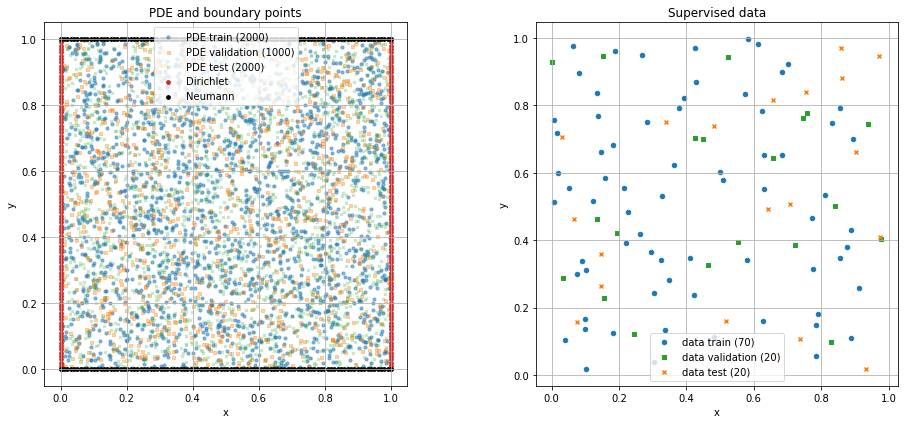

In [10]:
plot_points()


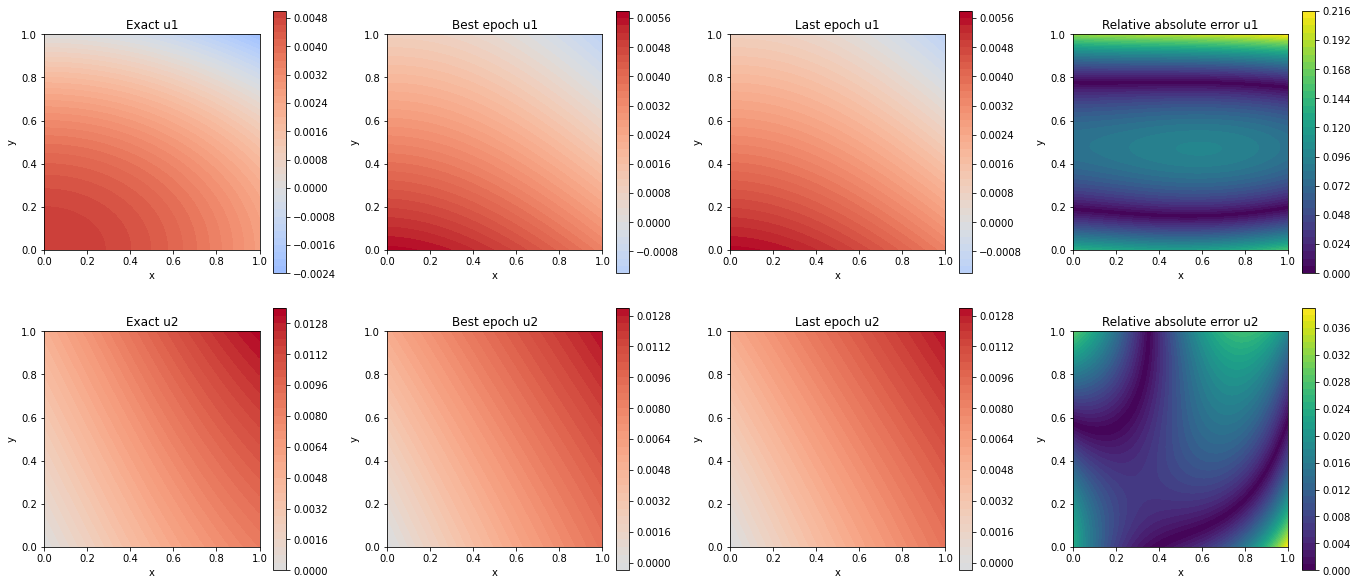

In [11]:
plot_displacement()


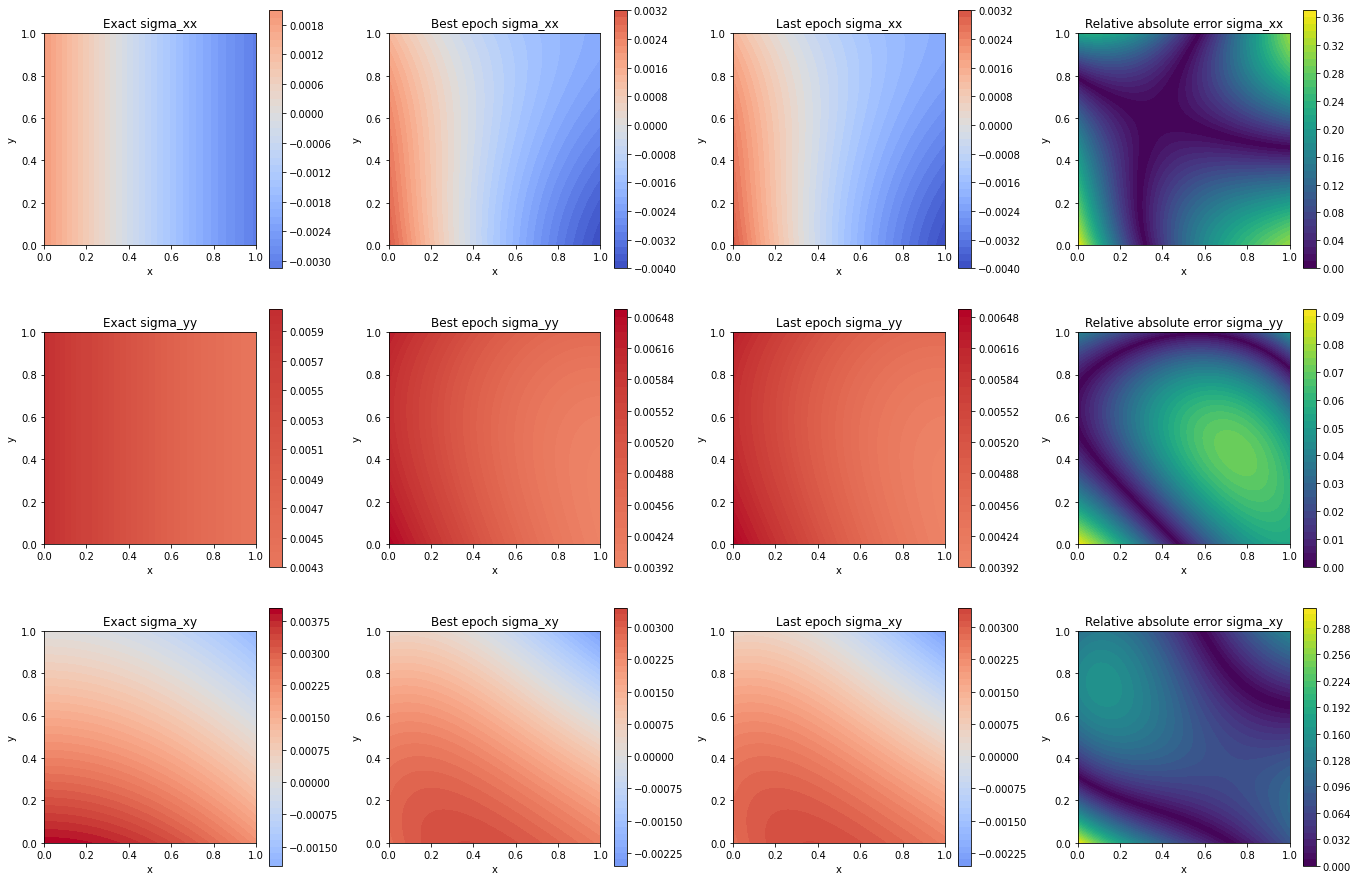

In [12]:
plot_stress()


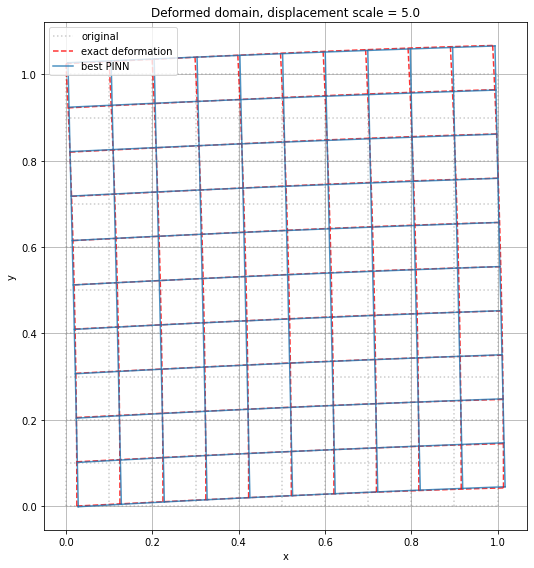

In [13]:
plot_deformed_domain(scale=5.0)


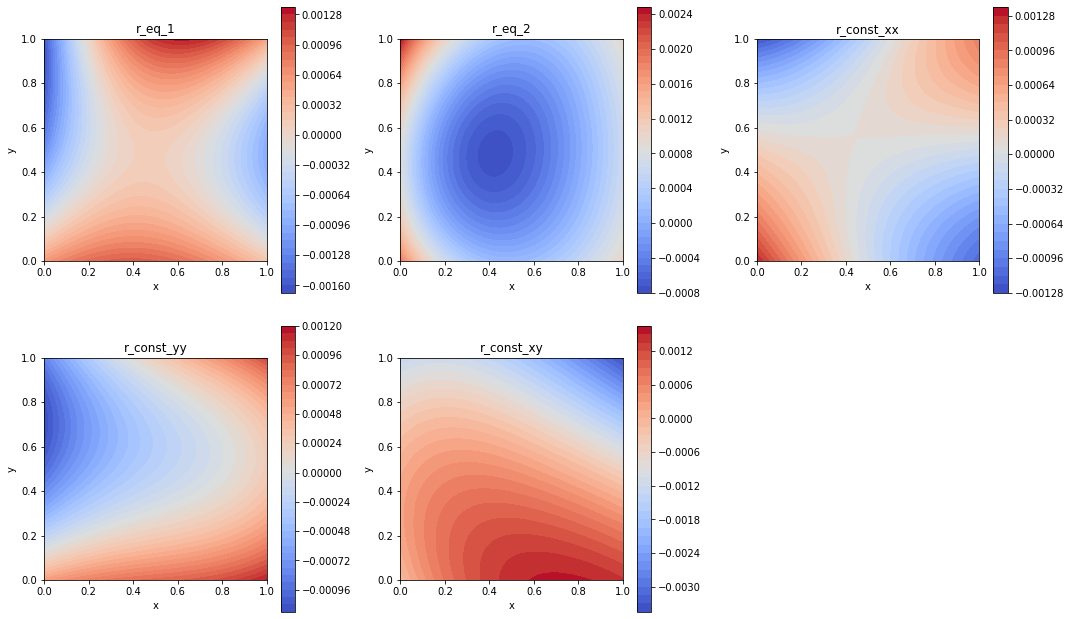

In [14]:
plot_residuals()


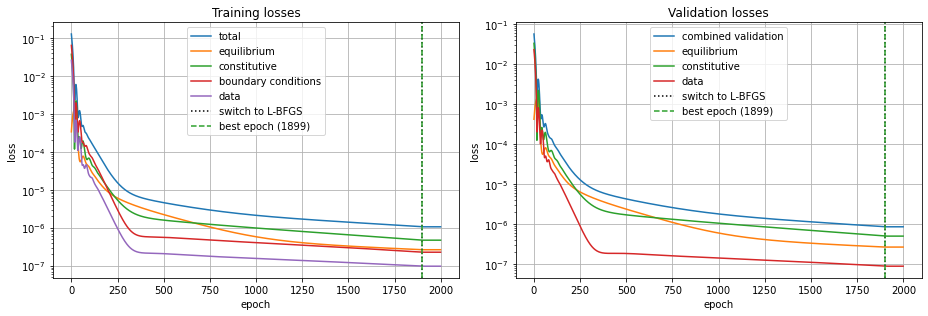

In [15]:
plot_loss()
